# Week 5 — Model, Tensor & Pipeline Parallelism

**Distributed Systems for Machine Learning**

---

Data parallelism replicates the model — but frontier models **don't fit** on one device. We must split the *model itself* across workers. Three orthogonal strategies (often combined as **3D parallelism**):

- **Tensor (intra-layer) parallelism** — split a single matmul across devices (Megatron-LM style).
- **Pipeline (inter-layer) parallelism** — put different *layers* on different devices and stream micro-batches through (GPipe, 1F1B).
- **Sharded data parallelism (ZeRO / FSDP)** — keep data parallelism but **shard** the optimizer state, gradients, and parameters so no device holds the whole model.

This week we implement the *mechanics* of each in NumPy, derive the **pipeline bubble** overhead, and build a **memory accountant** that explains exactly what ZeRO saves.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(5)
plt.rcParams["figure.figsize"]=(9,4.5); plt.rcParams["axes.grid"]=True

## 1. Tensor parallelism: splitting one matmul

Consider a linear layer $Y = XW$ with $W\in\mathbb{R}^{d\times h}$. We can split $W$ **column-wise** across $P$ devices: $W=[W_1|W_2|\dots|W_P]$. Each device computes $Y_p = X W_p$ (needs the full $X$, broadcast once), and the outputs are **concatenated** — an *all-gather*.

Alternatively, split **row-wise**: $W=[W_1;W_2;\dots]$ with $X$ split column-wise too; each device computes a partial product and we **all-reduce** (sum) the results. Megatron pairs a column-split layer with a row-split layer so the two collectives cancel into a single all-reduce per transformer block. Let's verify a column split is exact.

In [2]:
d,h,bs=16,32,8
X=np.random.randn(bs,d); W=np.random.randn(d,h)
Y_ref = X@W

P=4
Wcols=np.array_split(W, P, axis=1)      # column split
Yparts=[X@Wp for Wp in Wcols]           # each device, needs full X
Y_col=np.concatenate(Yparts, axis=1)    # all-gather
print("column-split exact?", np.allclose(Y_ref, Y_col))

# row split: split contraction dim
Wrows=np.array_split(W,P,axis=0); Xcols=np.array_split(X,P,axis=1)
Y_row=sum(Xc@Wr for Xc,Wr in zip(Xcols,Wrows))  # all-reduce (sum)
print("row-split exact?  ", np.allclose(Y_ref, Y_row))

column-split exact? True
row-split exact?   True


**Cost:** tensor parallelism needs a collective **inside every layer's forward and backward** — so it's only viable over very fast links (NVLink *within* a node), not across slow inter-node networks. That constraint dictates the layout of real clusters: tensor-parallel groups stay inside a node, pipeline/data parallelism span nodes.

## 2. Pipeline parallelism and the bubble

Put layer-stages on different devices: device 0 holds stages 1–k, device 1 holds k+1–2k, etc. A micro-batch flows forward 0→1→2→…, then gradients flow backward …→2→1→0. The problem: while device 0 works on micro-batch 1, devices 1..P-1 are **idle** — the *pipeline fill/drain bubble*.

With $P$ stages and $m$ micro-batches, ideal time is $m$ units but the pipeline takes $m + (P-1)$ units. **Bubble fraction:**
$$\text{bubble} = \frac{P-1}{m + P - 1}.$$
More micro-batches ($m\gg P$) shrink the bubble. We simulate the GPipe schedule and visualize device utilization.

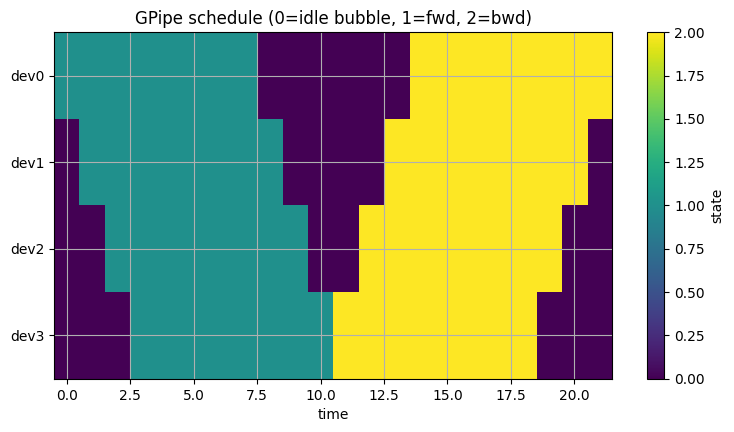

device utilization with m=8, P=4: 72.7%  (rest is bubble)


In [3]:
def gpipe_schedule(P=4, m=8):
    """Return a (P x time) busy matrix for GPipe: all forwards, then all backwards."""
    T = 2*(m + P - 1)   # forward fill+drain, then backward
    busy = np.zeros((P, T), dtype=int)
    # forward: micro-batch i enters stage 0 at time i, stage s at time i+s
    for i in range(m):
        for s in range(P):
            busy[s, i+s] = 1
    # backward (reverse stage order), starts after last forward
    off = m + P - 1
    for i in range(m):
        for s in range(P):
            busy[P-1-s, off + i + s] = 2
    return busy

busy=gpipe_schedule(P=4,m=8)
plt.imshow(busy, aspect="auto", cmap="viridis")
plt.yticks(range(4),[f"dev{ s}" for s in range(4)])
plt.xlabel("time"); plt.title("GPipe schedule (0=idle bubble, 1=fwd, 2=bwd)")
plt.colorbar(label="state"); plt.show()

util = (busy>0).mean()
print(f"device utilization with m=8, P=4: {util:.1%}  (rest is bubble)")

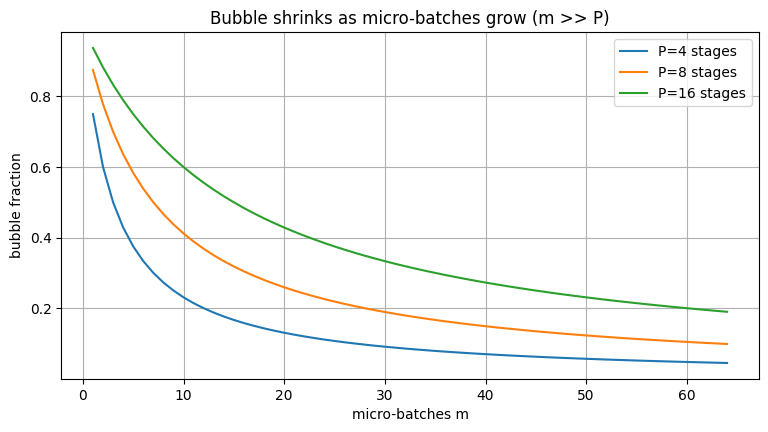

In [4]:
ms=np.arange(1,65)
for P in (4,8,16):
    plt.plot(ms, (P-1)/(ms+P-1), label=f"P={P} stages")
plt.xlabel("micro-batches m"); plt.ylabel("bubble fraction")
plt.title("Bubble shrinks as micro-batches grow (m >> P)"); plt.legend(); plt.show()

**1F1B (one-forward-one-backward)** scheduling (PipeDream/Megatron) interleaves forward and backward passes so backward of early micro-batches starts while later ones are still going forward. It has the *same* bubble fraction as GPipe but a much **smaller memory footprint**, because it doesn't need to stash activations for *all* $m$ micro-batches at once — only ~$P$ of them. Memory, not the bubble, is usually the real constraint.

## 3. ZeRO / FSDP: sharding the optimizer

In plain data parallelism every worker stores a **full copy** of: parameters ($\Psi$), gradients ($\Psi$), and optimizer state. For Adam in mixed precision the optimizer state (fp32 master weights + 2 moments) dwarfs the parameters — about $12\Psi$ bytes vs $2\Psi$ for fp16 weights. **ZeRO** shards these across the $P$ data-parallel workers:

| Stage | Shards | Per-device memory (params/grads/optim) |
|-------|--------|----------------------------------------|
| ZeRO-1 | optimizer state | $2\Psi + 2\Psi + \tfrac{12\Psi}{P}$ |
| ZeRO-2 | + gradients | $2\Psi + \tfrac{2\Psi}{P} + \tfrac{12\Psi}{P}$ |
| ZeRO-3 / FSDP | + parameters | $\tfrac{2\Psi + 2\Psi + 12\Psi}{P}$ |

ZeRO-3 reconstructs each layer's full params *on the fly* via **all-gather** (Week 2!) just before using it, then frees them — trading extra communication for memory. Let's build the accountant.

In [5]:
def memory_per_device(psi_params, P, stage=0, bytes_fp16=2, bytes_optim=12):
    """psi_params = number of parameters. Returns GB per device."""
    p  = bytes_fp16*psi_params                      # fp16 params
    g  = bytes_fp16*psi_params                      # fp16 grads
    o  = bytes_optim*psi_params                     # fp32 master + Adam moments
    if stage==0:   total = p + g + o
    elif stage==1: total = p + g + o/P
    elif stage==2: total = p + g/P + o/P
    elif stage==3: total = (p + g + o)/P
    return total/2**30

PSI = 7e9   # a 7B-parameter model
for P in (1,8,64):
    print(f"P={P:3d} data-parallel workers:")
    for st in range(4):
        print(f"   ZeRO-{st}: {memory_per_device(PSI,P,st):8.1f} GB/device")
    print()

P=  1 data-parallel workers:
   ZeRO-0:    104.3 GB/device
   ZeRO-1:    104.3 GB/device
   ZeRO-2:    104.3 GB/device
   ZeRO-3:    104.3 GB/device

P=  8 data-parallel workers:
   ZeRO-0:    104.3 GB/device
   ZeRO-1:     35.9 GB/device
   ZeRO-2:     24.4 GB/device
   ZeRO-3:     13.0 GB/device

P= 64 data-parallel workers:
   ZeRO-0:    104.3 GB/device
   ZeRO-1:     27.3 GB/device
   ZeRO-2:     14.5 GB/device
   ZeRO-3:      1.6 GB/device



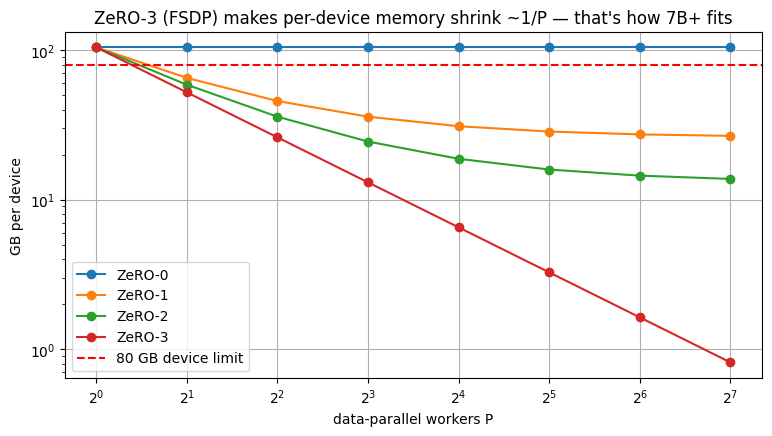

In [6]:
Ps=[1,2,4,8,16,32,64,128]
for st in range(4):
    plt.plot(Ps,[memory_per_device(PSI,p,st) for p in Ps],"o-",label=f"ZeRO-{st}")
plt.axhline(80,ls="--",color="red",label="80 GB device limit")
plt.xscale("log",base=2); plt.yscale("log")
plt.xlabel("data-parallel workers P"); plt.ylabel("GB per device")
plt.title("ZeRO-3 (FSDP) makes per-device memory shrink ~1/P — that's how 7B+ fits"); plt.legend(); plt.show()

## 4. Putting it together: 3D parallelism

Real frontier training combines all three along orthogonal axes:
- **Tensor-parallel** within a node (fast NVLink), size $t$.
- **Pipeline-parallel** across a few nodes, size $p$.
- **Data-parallel (FSDP)** across the rest, size $d$.

Total devices $= t \times p \times d$. The art is choosing the split so each collective rides the right link and memory fits. The pieces you need — all-reduce, all-gather, reduce-scatter, the bubble, the memory accountant — you've now built from scratch.

## Exercises

1. **Megatron block.** Chain a column-parallel linear → (elementwise GeLU) → row-parallel linear and show the whole block needs exactly **one** all-reduce in the forward pass. Why does the GeLU placement matter?
2. **1F1B memory.** Modify `gpipe_schedule` to a 1F1B schedule and count peak stashed activations for GPipe vs 1F1B. Confirm 1F1B peaks at ~$P$ micro-batches, not $m$.
3. **Optimal micro-batches.** Given fixed global batch and stage compute time, derive the $m$ that minimizes (bubble + per-microbatch overhead). 
4. **ZeRO-3 comm cost.** ZeRO-3 adds an all-gather of params in forward and backward plus a reduce-scatter of grads. Using Week 2 costs, compute the *extra* bytes/step vs ZeRO-1 for the 7B model, and the $P$ where memory savings justify it.
5. **Design challenge.** You have 64 GPUs (8 nodes × 8 GPUs, NVLink intra-node, slower InfiniBand inter-node) and a 30B model. Propose a $(t,p,d)$ split, justify which collective rides which link, and check per-device memory with your accountant.
